In [ ]:
# Image analysis with scikit-image
## an example of image analysis using scikit-image that runs on UCL HPC Myriad

In [30]:
# Environment
## Load packages
import glob, os
import skimage
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import napari_segment_blobs_and_things_with_membranes as nsbatwm
import napari_simpleitk_image_processing as nsitk

## set dirs
cwd = Path.cwd()
# Find the first parent that matches the target folder
for p in cwd.parents:
    if p.name == "UCL-Biosciences-Image-Analysis":
        DIR = p
        break
else:
    raise FileNotFoundError("Base directory 'UCL-Biosciences-Image-Analysis' not found in path.")

DATA_DIR = DIR / "input_data" / "BBBC006_v1_images_z_16"

In [2]:
# # let's have a look
# 2. List files
files = sorted(DATA_DIR.glob("*_w1*.tif"))[ :14]
files

### for a list of tifs
images = [ ]
for file in files:
    images.append(skimage.io.imread(file))
# skimage.io.imread_collection(files)

print(images[0].shape)
print('we have ', len(images), ' images')
print('each image has ', images[0].shape, ' pixels')

(520, 696)
we have  14  images
each image has  (520, 696)  pixels


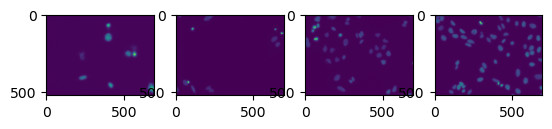

In [3]:
## Show a few images
fig, ax = plt.subplots(ncols = 4 )

ax[0].imshow(images[0])
ax[1].imshow(images[4])
ax[2].imshow(images[9])
ax[3].imshow(images[13])

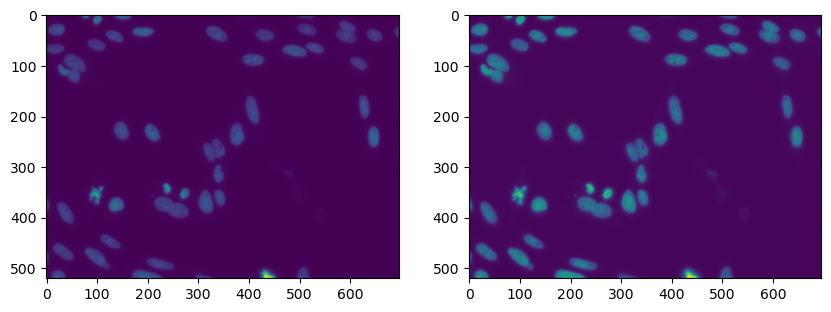

In [92]:
# local contrast
image = images[7]
# img = skimage.filters.gaussian(image)
img = skimage.exposure.equalize_adapthist(image)
# plt.imshow(img)
fig, ax = plt.subplots(1, 2, figsize = (10, 20))
ax[0].imshow(image)
ax[1].imshow(img)

0.016063612061839733


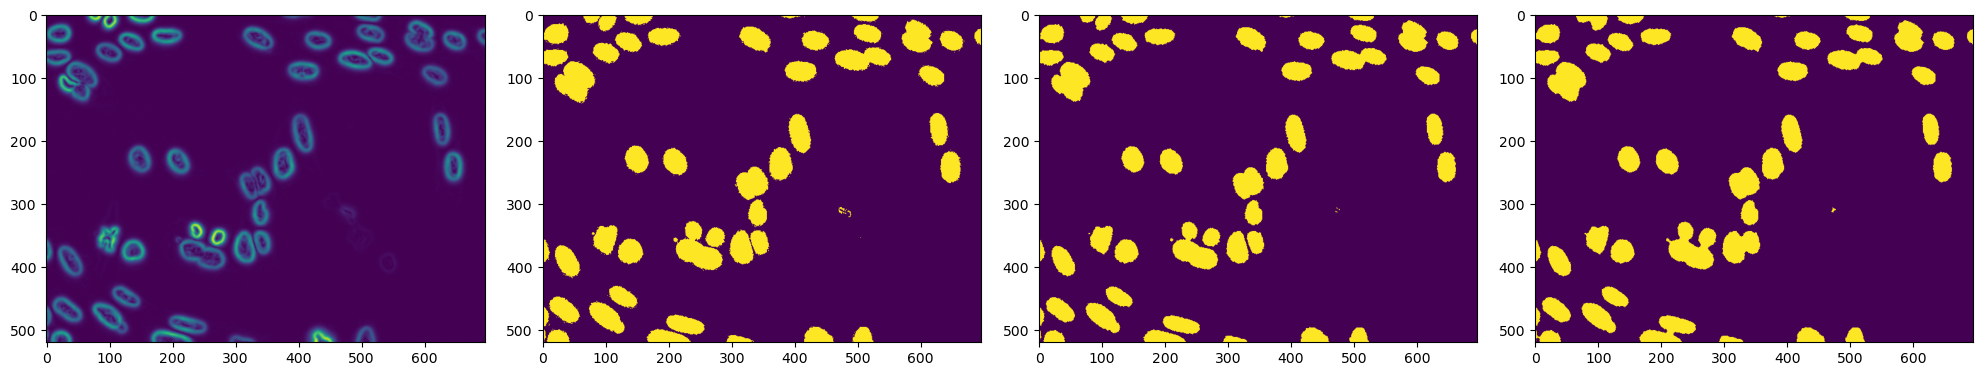

In [93]:
### background correction
from skimage.filters import sobel, gaussian, scharr

## find edges
edge = sobel(gaussian(img, sigma=2))
edge_sch = scharr(img)

### threshold and make mask
thresh = skimage.filters.threshold_li(edge_sch)
print(thresh)
mask = edge_sch > thresh
# mask = skimage.morphology.remove_small_objects(mask, 100)
mask = skimage.morphology.remove_small_holes(mask, 1000)
mask_erode = skimage.morphology.binary_erosion(mask, mode = 'max')
mask_binary_close = skimage.morphology.binary_closing(mask_erode, skimage.morphology.disk(3))

plt.close('all')
fig, ax = plt.subplots(1,4, figsize=(20, 20))
fig.tight_layout()
ax[0].imshow(edge)
ax[1].imshow(mask)
ax[2].imshow(mask_erode)
ax[3].imshow(mask_binary_close)

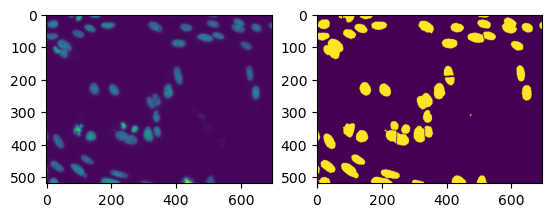

In [99]:
### alreayd looks pretty good
## just need to split the three nuclei on the right
## try napari_segment_blobs_and_things_with_membranes  function split_touching_objects 
split_objects = nsbatwm.split_touching_objects(mask_binary_close, sigma = 3) # sigma controls where to split. smaller sigma = more splits
## this looks pretty good
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[1].imshow(split_objects)

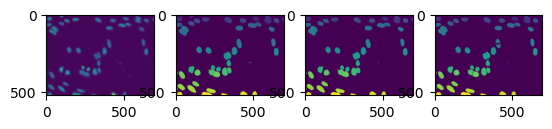

In [95]:
### label the different objects
## can label the objects before or after splitting them
## from Robert Haase's amazing napari plug ins
split_labels = nsitk.touching_objects_labeling(split_objects)
touching_labels = nsitk.touching_objects_labeling(mask_binary_close)
mask_labels = nsitk.touching_objects_labeling(mask)

fig, ax = plt.subplots(1,4)
ax[0].imshow(img)
ax[1].imshow(mask_labels)
ax[2].imshow(touching_labels)
ax[3].imshow(split_labels)

In [96]:
# Count